In [ ]:
# --- CELL 1: SETUP ---
!pip install grad-cam
!pip install torchsummary

import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn #lớp neural network
import torch.optim as optim #Adam, SGD
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models
from torchvision.models import EfficientNet_B2_Weights, ResNet50_Weights, DenseNet121_Weights
from torch.optim.lr_scheduler import ReduceLROnPlateau #Giảm learning rate khi val los

# Thiết lập device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Seed để tái lập kết quả
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 74.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44284 sha256=545cbc93a97f87045a5c89ea7235518bbd7be225312c21305082e218e98c8848
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam
Using device: cuda


In [ ]:
# --- CELL 2: DATA DOWNLOAD (KAGGLE OFFICIAL) ---
import os
from google.colab import files

# 1. Upload file kaggle.json
print(" Vui lòng bấm nút 'Choose Files' bên dưới:")
uploaded = files.upload()

# 2. Cấu hình Kaggle CLI
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 3. Tải dataset từ Kaggle
print("\nĐang tải dữ liệu từ Kaggle...")
!kaggle datasets download -d tawsifurrahman/covid19-radiography-database
!unzip -q covid19-radiography-database.zip
print(" Tải và giải nén xong! Dữ liệu nằm trong folder 'COVID-19_Radiography_Dataset'")

 Vui lòng bấm nút 'Choose Files' bên dưới:


Saving kaggle.json to kaggle.json

Đang tải dữ liệu từ Kaggle...
Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database
License(s): copyright-authors
 94% 732M/778M [00:03<00:00, 183MB/s]
100% 778M/778M [00:07<00:00, 111MB/s]
 Tải và giải nén xong! Dữ liệu nằm trong folder 'COVID-19_Radiography_Dataset'


 Đang kiểm tra dữ liệu tại: /content/COVID-19_Radiography_Dataset
------------------------------------------------------------
   - Normal: 10192 ảnh
   - COVID: 3616 ảnh
   - Viral Pneumonia: 1345 ảnh
   - Lung_Opacity: 6012 ảnh
------------------------------------------------------------
 TỔNG CỘNG: 21165 ẢNH

 BẢNG SỐ LIỆU CHO BÁO CÁO:


,Loại bệnh,Số lượng ảnh
0,Normal,10192
1,Lung_Opacity,6012
2,COVID,3616
3,Viral Pneumonia,1345


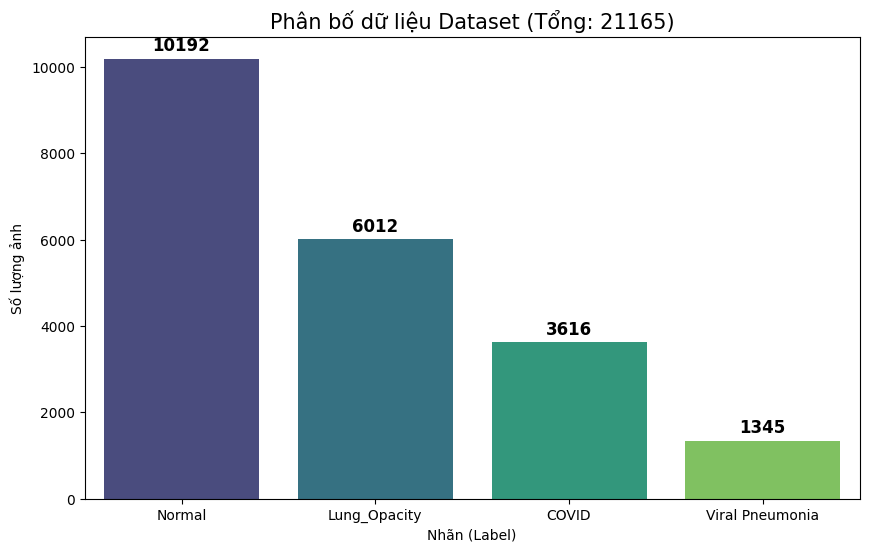

In [ ]:
# --- CELL: KIỂM TRA THỐNG KÊ DATASET ---
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đường dẫn dataset
dataset_path = '/content/COVID-19_Radiography_Dataset'

# CHỈ ĐỊNH RÕ 4 LỚP CẦN ĐẾM (Để tránh đếm nhầm folder rác hay folder masks)
target_classes = ['Normal', 'COVID', 'Viral Pneumonia', 'Lung_Opacity']

stats = []
total_images = 0

print(f" Đang kiểm tra dữ liệu tại: {dataset_path}")
print("-" * 60)

if os.path.exists(dataset_path):
    for class_name in target_classes:
        # Đường dẫn chuẩn: Dataset/Tên_Bệnh/images/
        class_dir = os.path.join(dataset_path, class_name)
        image_dir = os.path.join(class_dir, 'images')

        # Kiểm tra xem folder images có tồn tại không
        if os.path.exists(image_dir):
            target_dir = image_dir
        elif os.path.exists(class_dir): # Dự phòng nếu không có folder images con
            target_dir = class_dir
        else:
            print(f" Không tìm thấy folder: {class_name}")
            continue

        # Đếm chính xác file ảnh (loại trừ file hệ thống)
        # Sử dụng glob để chỉ lấy đúng định dạng ảnh
        image_files = glob.glob(os.path.join(target_dir, "*.png")) + \
                      glob.glob(os.path.join(target_dir, "*.jpg")) + \
                      glob.glob(os.path.join(target_dir, "*.jpeg"))

        count = len(image_files)
        total_images += count

        stats.append({
            'Loại bệnh': class_name,
            'Số lượng ảnh': count
        })
        print(f"   - {class_name}: {count} ảnh")

    # Tạo DataFrame
    df_stats = pd.DataFrame(stats)

    # Sắp xếp và RESET INDEX để vẽ biểu đồ không bị lệch số
    df_stats = df_stats.sort_values(by='Số lượng ảnh', ascending=False).reset_index(drop=True)

    print("-" * 60)
    print(f" TỔNG CỘNG: {total_images} ẢNH")
    print("\n BẢNG SỐ LIỆU CHO BÁO CÁO:")
    display(df_stats)

    # Vẽ biểu đồ
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=df_stats, x='Loại bệnh', y='Số lượng ảnh', palette='viridis', hue='Loại bệnh')

    plt.title(f'Phân bố dữ liệu Dataset (Tổng: {total_images})', fontsize=15)
    plt.ylabel('Số lượng ảnh')
    plt.xlabel('Nhãn (Label)')

    # Gắn số lên cột (Dùng ax.containers để gắn chuẩn vị trí)
    for i in ax.containers:
        ax.bar_label(i, padding=3, fontsize=12, fontweight='bold')

    plt.show()

else:
    print(" Lỗi: Không tìm thấy đường dẫn dataset. Hãy chạy Cell tải dữ liệu trước!")

In [ ]:
# --- CELL 3: DATA PREPARATION (FIXED - FULL DATASET) ---
import glob
import os
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from PIL import Image

base_path = '/content/COVID-19_Radiography_Dataset'

# 1. CẬP NHẬT DANH SÁCH LỚP
classes = ['Normal', 'COVID', 'Viral Pneumonia']

image_paths = []
labels = []
class_counts = {} # Biến đếm để in báo cáo

print(" Đang quét toàn bộ dữ liệu...")

if os.path.exists(base_path):
    for label_idx, class_name in enumerate(classes):
        # Cấu trúc Kaggle thường là: Dataset/Normal/images/*.png
        search_path = os.path.join(base_path, class_name, 'images', '*')

        # Check dự phòng nếu không có folder 'images' con
        if not os.path.exists(os.path.join(base_path, class_name, 'images')):
            search_path = os.path.join(base_path, class_name, '*')

        files = glob.glob(search_path)

        count = 0
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append(f)
                labels.append(label_idx)
                count += 1

        class_counts[class_name] = count
        print(f"   - {class_name}: Đã nạp {count} ảnh")

    print("-" * 30)
    print(f" TỔNG CỘNG: {len(image_paths)} ảnh")
    print(" Chi tiết:", class_counts)

    if len(image_paths) == 0:
        print(" LỖI: Không tìm thấy ảnh. Hãy kiểm tra lại Cell 2 xem đã tải và giải nén chưa!")
    else:
        X_train, X_temp, y_train, y_temp = train_test_split(image_paths, labels, test_size=0.3, stratify=labels, random_state=42)
        X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

        print(f" Đã chia dataset:")
        print(f"   - Train set: {len(X_train)} ảnh")
        print(f"   - Val set  : {len(X_val)} ảnh")
        print(f"   - Test set : {len(X_test)} ảnh")

else:
    print(f" Không tìm thấy đường dẫn: {base_path}")
    print("Vui lòng chạy lại Cell 2 để tải dữ liệu.")

# Dataset Class
class ChestXrayDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):#hàm dựng lưu trữ thông tin đầu vào
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self): #hàm đếm số lượng sẽ tả về tổng số lượng mẫu trong dataset
        return len(self.image_paths)

    def __getitem__(self, idx): #hàm lấy dữ liệu
        img_path = self.image_paths[idx]
        # Mở ảnh và convert sang RGB (chuyển x-ray từ 1 kênh sang 3 kênh màu cho model)
        image = Image.open(img_path).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

 Đang quét toàn bộ dữ liệu...
   - Normal: Đã nạp 10192 ảnh
   - COVID: Đã nạp 3616 ảnh
   - Viral Pneumonia: Đã nạp 1345 ảnh
------------------------------
 TỔNG CỘNG: 15153 ảnh
 Chi tiết: {'Normal': 10192, 'COVID': 3616, 'Viral Pneumonia': 1345}
 Đã chia dataset:
   - Train set: 10607 ảnh
   - Val set  : 2273 ảnh
   - Test set : 2273 ảnh


In [ ]:
# --- CELL 4: DATALOADERS ---
# Augmentation cho Train set (chống overfitting)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Chuẩn ImageNet
])

# Chỉ Resize và Normalize cho Val/Test
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = ChestXrayDataset(X_train, y_train, transform=train_transform)
val_dataset = ChestXrayDataset(X_val, y_val, transform=test_transform)
test_dataset = ChestXrayDataset(X_test, y_test, transform=test_transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# --- CELL 5: MODEL FACTORY ---
def get_model(model_name, num_classes=3):
    if model_name == 'resnet50':
        model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        # Fine-tuning: Freeze toàn bộ trước
        for param in model.parameters():
            param.requires_grad = False

        # UNFREEZE layer4 (2 blocks cuối)
        for param in model.layer4.parameters():
            param.requires_grad = True

        # Thay đổi fully connected layer
        model.fc = nn.Sequential(
            nn.Linear(model.fc.in_features, 256),
            nn.ReLU(), #hàm kích hoạt phi tuyến
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    elif model_name == 'densenet121':
        model = models.densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
        # Freeze toàn bộ
        for param in model.parameters():
            param.requires_grad = False

        # UNFREEZE denseblock4 (block cuối)
        for param in model.features.denseblock4.parameters():
            param.requires_grad = True

        model.classifier = nn.Sequential(
            nn.Linear(model.classifier.in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    elif model_name == 'efficientnet_b2':
        model = models.efficientnet_b2(weights=EfficientNet_B2_Weights.IMAGENET1K_V1)
        # Freeze toàn bộ
        for param in model.parameters():
            param.requires_grad = False

        # UNFREEZE 4 layer cuối của features
        # Lưu ý: efficientnet_b2 features là nn.Sequential
        # Chúng ta cần xác định chính xác các layer
        total_layers = len(list(model.features.children()))
        # Unfreeze 4 layer cuối
        for i, child in enumerate(model.features.children()):
            if i >= total_layers - 4:  # 4 layer cuối
                for param in child.parameters():
                    param.requires_grad = True

        model.classifier[1] = nn.Sequential(
            nn.Dropout(p=0.3, inplace=True),
            nn.Linear(model.classifier[1].in_features, num_classes)
        )

    else:
        raise ValueError("Model not supported")

    return model.to(device)

In [ ]:
# --- CELL 6: TRAINING FUNCTIONS ---
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=15, model_name="model", patience=5):
    best_acc = 0.0
    best_epoch = 0
    history = {'train_loss': [], 'val_acc': [], 'lr': []}

    # Sửa: Bỏ tham số 'verbose' vì không được hỗ trợ trong phiên bản cũ
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

    print(f"--- Bắt đầu train {model_name} ---")
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)

        # Validation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = correct / total
        history['train_loss'].append(epoch_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        # Cập nhật scheduler
        scheduler.step(val_acc)

        # Kiểm tra xem LR có thay đổi không
        current_lr = optimizer.param_groups[0]['lr']
        if epoch > 0 and current_lr != history['lr'][-2]:
            print(f"    Learning rate giảm xuống: {current_lr:.6f}")

        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f} - Val Acc: {val_acc:.4f} - LR: {current_lr:.6f}")

        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            best_epoch = epoch
            torch.save(model.state_dict(), f"{model_name}_best.pth")
            print(f" Lưu model tốt nhất tại epoch {epoch+1}")

        # Early stopping
        if epoch - best_epoch >= patience:
            print(f" Early stopping tại epoch {epoch+1} (không cải thiện sau {patience} epoch)")
            break

    # Load lại weights tốt nhất
    model.load_state_dict(torch.load(f"{model_name}_best.pth"))
    print(f" Best accuracy: {best_acc:.4f} tại epoch {best_epoch+1}")

    return history

In [ ]:
# --- CELL 7: EXECUTE TRAINING ---
model_names = ['resnet50', 'densenet121', 'efficientnet_b2']
trained_models = {}
histories = {}

# Tính class weight để giải quyết imbalance
print("Đang tính class weight...")
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class weights: {class_weights}")

# Sử dụng class weight trong loss
criterion = nn.CrossEntropyLoss(weight=class_weights)

for name in model_names:
    print(f"\n{'='*50}")
    print(f"Training Model: {name}")
    print(f"{'='*50}")
    model = get_model(name)

    # Optimizer chỉ update các tham số có requires_grad=True
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

    # GIẢM EPOCH XUỐNG 5 để chạy nhanh hơn
    history = train_model(model, train_loader, val_loader, criterion, optimizer,
                         num_epochs=5, model_name=name, patience=3)  # Giảm patience xuống 3

    # Load lại weights tốt nhất
    model.load_state_dict(torch.load(f"{name}_best.pth"))
    trained_models[name] = model
    histories[name] = history

Đang tính class weight...
Class weights: tensor([0.4956, 1.3969, 3.7534], device='cuda:0')

Training Model: resnet50
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 105MB/s]


--- Bắt đầu train resnet50 ---
Epoch 1/5 - Loss: 0.3138 - Val Acc: 0.9600 - LR: 0.001000
 Lưu model tốt nhất tại epoch 1
Epoch 2/5 - Loss: 0.1728 - Val Acc: 0.9120 - LR: 0.001000
Epoch 3/5 - Loss: 0.1325 - Val Acc: 0.9622 - LR: 0.001000
 Lưu model tốt nhất tại epoch 3
Epoch 4/5 - Loss: 0.1145 - Val Acc: 0.9670 - LR: 0.001000
 Lưu model tốt nhất tại epoch 4
Epoch 5/5 - Loss: 0.1002 - Val Acc: 0.9798 - LR: 0.001000
 Lưu model tốt nhất tại epoch 5
 Best accuracy: 0.9798 tại epoch 5

Training Model: densenet121
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 131MB/s]


--- Bắt đầu train densenet121 ---
Epoch 1/5 - Loss: 0.2867 - Val Acc: 0.9375 - LR: 0.001000
 Lưu model tốt nhất tại epoch 1
Epoch 2/5 - Loss: 0.1662 - Val Acc: 0.9648 - LR: 0.001000
 Lưu model tốt nhất tại epoch 2
Epoch 3/5 - Loss: 0.1341 - Val Acc: 0.9604 - LR: 0.001000


In [ ]:
# --- CELL 8: COMPARISON & METRICS (ĐÃ CẢI THIỆN: THÊM CONFUSION MATRIX VÀ METRIC Y KHOA) ---
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

def evaluate_model(model, loader):
    model.eval()
    y_true = []
    y_pred = []
    y_probs = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())

    return y_true, y_pred, y_probs

results = []

for name, model in trained_models.items():
    print(f"\n{'='*50}")
    print(f"Đánh giá model: {name}")
    print(f"{'='*50}")

    y_true, y_pred, y_probs = evaluate_model(model, test_loader)

    # Classification report
    report = classification_report(y_true, y_pred, target_names=classes, output_dict=True)

    # Tính các metric y khoa cho từng lớp
    precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, labels=[0,1,2])

    # Tính specificity (TN / (TN + FP)) và NPV (TN / (TN + FN))
    conf_mat = confusion_matrix(y_true, y_pred, labels=[0,1,2])

    # Tính cho từng lớp
    metrics_per_class = []
    for i, class_name in enumerate(classes):
        TP = conf_mat[i, i]
        FP = conf_mat[:, i].sum() - TP
        FN = conf_mat[i, :].sum() - TP
        TN = conf_mat.sum() - (TP + FP + FN)

        sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0  # Recall
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
        ppv = TP / (TP + FP) if (TP + FP) > 0 else 0  # Precision
        npv = TN / (TN + FN) if (TN + FN) > 0 else 0

        metrics_per_class.append({
            'Class': class_name,
            'Sensitivity': sensitivity,
            'Specificity': specificity,
            'PPV': ppv,
            'NPV': npv,
            'F1': f1[i],
            'Support': support[i]
        })

    # Thêm vào bảng kết quả
    results.append({
        'Model': name,
        'Accuracy': report['accuracy'],
        'Macro F1': report['macro avg']['f1-score'],
        'COVID F1': report['COVID']['f1-score'],
        'COVID Sensitivity': metrics_per_class[1]['Sensitivity'],  # Class 1 là COVID
        'COVID Specificity': metrics_per_class[1]['Specificity'],
        'COVID PPV': metrics_per_class[1]['PPV'],
        'COVID NPV': metrics_per_class[1]['NPV']
    })

    # In report
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=classes))

    # Vẽ confusion matrix
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    # In metrics chi tiết cho từng lớp
    print("\nChi tiết metrics y khoa:")
    for i, metric in enumerate(metrics_per_class):
        print(f"\n{classes[i]}:")
        print(f"  Sensitivity (Recall): {metric['Sensitivity']:.4f}")
        print(f"  Specificity: {metric['Specificity']:.4f}")
        print(f"  PPV (Precision): {metric['PPV']:.4f}")
        print(f"  NPV: {metric['NPV']:.4f}")
        print(f"  F1-Score: {metric['F1']:.4f}")
        print(f"  Support: {metric['Support']}")

# Hiển thị bảng so sánh
df_results = pd.DataFrame(results)
print("\n" + "="*80)
print("BẢNG SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH")
print("="*80)
print(df_results.to_string())

# Vẽ biểu đồ
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Biểu đồ Accuracy
axes[0, 0].bar(df_results['Model'], df_results['Accuracy'])
axes[0, 0].set_title("So sánh Accuracy")
axes[0, 0].set_ylim(0.8, 1.0)
axes[0, 0].set_ylabel('Accuracy')

# Biểu đồ COVID Sensitivity
axes[0, 1].bar(df_results['Model'], df_results['COVID Sensitivity'])
axes[0, 1].set_title("Sensitivity cho COVID (Quan trọng nhất)")
axes[0, 1].set_ylim(0.8, 1.0)
axes[0, 1].set_ylabel('Sensitivity')

# Biểu đồ COVID Specificity
axes[1, 0].bar(df_results['Model'], df_results['COVID Specificity'])
axes[1, 0].set_title("Specificity cho COVID")
axes[1, 0].set_ylim(0.8, 1.0)
axes[1, 0].set_ylabel('Specificity')

# Biểu đồ Macro F1
axes[1, 1].bar(df_results['Model'], df_results['Macro F1'])
axes[1, 1].set_title("Macro F1-Score")
axes[1, 1].set_ylim(0.8, 1.0)
axes[1, 1].set_ylabel('F1-Score')

plt.tight_layout()
plt.show()

In [ ]:
# --- CELL 9: XAI UTILS ---
import cv2
import numpy as np
import torch

def get_gradcam(model, input_tensor, original_img_np, model_name):
    # 1. Xác định Target Layer chính xác
    target_layer = None
    name_lower = model_name.lower()

    if 'resnet' in name_lower:
        target_layer = model.layer4[-1] # ResNet: Block cuối cùng
    elif 'densenet' in name_lower:
        target_layer = model.features.denseblock4 # DenseNet: Block dày đặc cuối
    elif 'efficientnet' in name_lower:
        # EfficientNet: Block conv cuối cùng trước khi pooling
        # features[-1] thường là Conv2d 1x1 output 1280/1408 channels
        target_layer = model.features[-1]

    if target_layer is None:
        print(f" Không tìm thấy target layer cho {model_name}")
        return None

    # 2. Hook để lấy Gradients và Activations
    gradients = []
    activations = []

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0]) # Lưu gradient

    def forward_hook(module, input, output):
        activations.append(output)       # Lưu feature map

    # Đăng ký hook
    handle_f = target_layer.register_forward_hook(forward_hook)
    handle_b = target_layer.register_full_backward_hook(backward_hook)

    try:
        # 3. Forward & Backward Pass
        model.zero_grad()
        output = model(input_tensor)

        # Chọn class có xác suất cao nhất để soi
        pred_idx = output.argmax(dim=1).item()
        score = output[0, pred_idx]

        score.backward() # Lan truyền ngược để tính độ quan trọng

        # 4. Tính toán Grad-CAM
        if not gradients or not activations:
            return None

        # Global Average Pooling trên gradients (trọng số alpha)
        pooled_gradients = torch.mean(gradients[0], dim=[0, 2, 3])
        activation = activations[0][0] # [Channels, H, W]

        # Nhân trọng số vào feature map
        for i in range(activation.shape[0]):
            activation[i, :, :] *= pooled_gradients[i]

        # Tổng hợp các kênh thành 1 bản đồ nhiệt (Heatmap)
        heatmap = torch.mean(activation, dim=0).cpu().detach().numpy()

        # ReLU: Chỉ lấy phần ảnh hưởng dương (tích cực)
        heatmap = np.maximum(heatmap, 0)

        # Chuẩn hóa về [0, 1]
        if np.max(heatmap) != 0:
            heatmap /= np.max(heatmap)

        # Resize về kích thước ảnh gốc
        heatmap = cv2.resize(heatmap, (224, 224))

        # Tô màu
        heatmap_uint8 = np.uint8(255 * heatmap)
        heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

        # Chồng ảnh (Overlay)
        original_uint8 = np.uint8(original_img_np * 255)
        original_bgr = cv2.cvtColor(original_uint8, cv2.COLOR_RGB2BGR)
        overlay = cv2.addWeighted(original_bgr, 0.6, heatmap_color, 0.4, 0)
        overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

        return overlay_rgb

    except Exception as e:
        print(f" Lỗi tính toán GradCAM: {e}")
        return None
    finally:
        # Gỡ hook để tránh tốn bộ nhớ cho lần sau
        handle_f.remove()
        handle_b.remove()

def get_saliency(model, input_tensor):
    # Saliency Map: Pixel nào thay đổi làm thay đổi output nhiều nhất?
    input_tensor.requires_grad_()
    model.eval()

    # Forward
    output = model(input_tensor)
    output_idx = output.argmax()
    score = output[0, output_idx]

    # Backward
    model.zero_grad()
    score.backward()

    # Lấy giá trị tuyệt đối của đạo hàm tại input (Saliency)
    saliency, _ = torch.max(input_tensor.grad.data.abs(), dim=1)
    saliency = saliency.reshape(224, 224).cpu().numpy()

    # Chuẩn hóa
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)

    # Loại bỏ nhiễu nền yếu để bản đồ rõ hơn (Thresholding)
    saliency[saliency < 0.2] = 0

    return saliency

In [ ]:
# --- CELL 10: HỆ THỐNG CHẨN ĐOÁN & XAI (ALL-IN-ONE FIX) ---
import cv2
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
from ipywidgets import interact, widgets, FileUpload, Layout
import io
from IPython.display import display, HTML, clear_output

# ==========================================
# 1. CÁC HÀM XỬ LÝ ẢNH & XAI (ĐỊNH NGHĨA TẠI CHỖ ĐỂ TRÁNH LỖI)
# ==========================================

def get_gradcam_mask(model, input_tensor, model_name):
    """Tính toán vùng kích hoạt (Grad-CAM)"""
    target_layer = None
    name_lower = model_name.lower()

    # Chọn layer cuối cùng có thông tin không gian
    if 'resnet' in name_lower:
        target_layer = model.layer4[-1]
    elif 'densenet' in name_lower:
        target_layer = model.features.denseblock4
    elif 'efficientnet' in name_lower:
        target_layer = model.features[-1]

    if target_layer is None: return None

    gradients = []
    activations = []

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])
    def forward_hook(module, input, output):
        activations.append(output)

    handle_f = target_layer.register_forward_hook(forward_hook)
    handle_b = target_layer.register_full_backward_hook(backward_hook)

    try:
        model.zero_grad()
        output = model(input_tensor)
        pred_idx = output.argmax(dim=1).item()
        output[0, pred_idx].backward()

        if not gradients or not activations: return None

        pooled_gradients = torch.mean(gradients[0], dim=[0, 2, 3])
        activation = activations[0][0]

        for i in range(activation.shape[0]):
            activation[i, :, :] *= pooled_gradients[i]

        heatmap = torch.mean(activation, dim=0).cpu().detach().numpy()
        heatmap = np.maximum(heatmap, 0) # ReLU

        if np.max(heatmap) != 0:
            heatmap /= np.max(heatmap) # Normalize

        heatmap = cv2.resize(heatmap, (224, 224))
        return heatmap

    except Exception as e:
        return None
    finally:
        handle_f.remove()
        handle_b.remove()

def get_combined_xai(model, input_tensor, original_img_np, model_name):
    """
    Kết hợp Saliency Map và Grad-CAM.
    Logic: Pixel quan trọng = Độ nhạy pixel (Saliency) * Vùng quan trọng (Grad-CAM)
    """
    # A. Tính Saliency Map
    input_tensor.requires_grad_()
    model.eval()
    model.zero_grad()

    output = model(input_tensor)
    output_idx = output.argmax()
    output[0, output_idx].backward()

    saliency, _ = torch.max(input_tensor.grad.data.abs(), dim=1)
    saliency = saliency.reshape(224, 224).cpu().numpy()

    # Làm mịn Saliency (Gaussian Blur) để bớt nhiễu hạt
    saliency = cv2.GaussianBlur(saliency, (7, 7), 0)

    # B. Lấy Grad-CAM Mask
    gradcam_mask = get_gradcam_mask(model, input_tensor, model_name)

    # C. KẾT HỢP: Lọc nhiễu
    # Chỉ giữ lại Saliency nằm trong vùng Grad-CAM
    if gradcam_mask is not None:
        combined_map = saliency * gradcam_mask
    else:
        combined_map = saliency

    # Chuẩn hóa về 0-1
    if combined_map.max() > 0:
        combined_map = (combined_map - combined_map.min()) / (combined_map.max() - combined_map.min())

    # D. Tạo ảnh Visualization cho Grad-CAM (Heatmap chồng lên ảnh gốc)
    gradcam_vis = np.zeros_like(original_img_np)
    if gradcam_mask is not None:
        heatmap_uint8 = np.uint8(255 * gradcam_mask)
        heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
        original_uint8 = np.uint8(original_img_np * 255)
        original_bgr = cv2.cvtColor(original_uint8, cv2.COLOR_RGB2BGR)
        gradcam_overlay = cv2.addWeighted(original_bgr, 0.6, heatmap_color, 0.4, 0)
        gradcam_vis = cv2.cvtColor(gradcam_overlay, cv2.COLOR_BGR2RGB)

    return gradcam_vis, combined_map

# ==========================================
# 2. GIAO DIỆN NGƯỜI DÙNG (UI) & LOGIC TÍNH TOÁN
# ==========================================

# Style Header
header_html = """
<div style="background: linear-gradient(to right, #0f2027, #203a43, #2c5364); padding:15px; border-radius:10px; color:white; text-align:center; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
    <h2 style="margin:0; font-family: sans-serif;"> HỆ THỐNG CHẨN ĐOÁN ĐA PHƯƠNG THỨC</h2>
    <p style="margin:5px 0 0 0; font-size:13px; opacity:0.8;">Deep Learning (Vision) + Clinical Heuristics (Logic)</p>
</div>
"""

# Widgets
uploader = FileUpload(accept='image/*', multiple=False, layout=Layout(width='100%', margin='10px 0'))
model_selector = widgets.Dropdown(options=model_names, value='resnet50', description='Model AI:', layout=Layout(width='98%'))

# Checkbox Triệu chứng (Đầy đủ)
lbl_symptom = widgets.Label(" CHECK CÁC TRIỆU CHỨNG LÂM SÀNG:")
chk_fever = widgets.Checkbox(value=False, description='Sốt cao (>38°C)')
chk_cough = widgets.Checkbox(value=False, description='Ho khan / Ho có đờm')
chk_breath = widgets.Checkbox(value=False, description='Khó thở / Tức ngực ( Nguy hiểm)')
chk_loss_smell = widgets.Checkbox(value=False, description='Mất khứu giác/vị giác (Đặc thù COVID)')
chk_fatigue = widgets.Checkbox(value=False, description='Mệt mỏi, đau nhức cơ')

btn_predict = widgets.Button(
    description="TIẾN HÀNH PHÂN TÍCH",
    button_style='primary',
    icon='fa-heartbeat',
    layout=Layout(width='100%', height='50px', margin='15px 0')
)
output_area = widgets.Output()

def predict_smart(change):
    output_area.clear_output()

    # 1. Kiểm tra ảnh
    if not uploader.value:
        with output_area: display(HTML("<div style='background:#f8d7da; color:#721c24; padding:10px; border-radius:5px;'> <b>LỖI:</b> Vui lòng upload ảnh X-quang phổi trước!</div>"))
        return

    # Load & Preprocess ảnh
    uploaded_file = list(uploader.value.values())[0]
    img_pil = Image.open(io.BytesIO(uploaded_file['content'])).convert("RGB")
    img_tensor = test_transform(img_pil).unsqueeze(0).to(device)
    img_np = np.array(img_pil.resize((224, 224))) / 255.0

    # 2. Dự đoán AI (Với Temperature Scaling)
    model_name = model_selector.value
    model = trained_models[model_name]
    model.eval()

    # --- QUAN TRỌNG: Temperature Scaling ---
    # T càng lớn (2.0 - 3.0) thì xác suất càng "phẳng" (bớt tự tin thái quá).
    # Ví dụ: T=1 (Gốc): Normal 99.9%, Covid 0.1% -> Rất khó thay đổi.
    #        T=2.5    : Normal 60.0%, Covid 40.0% -> Triệu chứng sẽ quyết định.
    T = 2.5

    with torch.no_grad():
        logits = model(img_tensor)
        probs_ai = F.softmax(logits / T, dim=1).cpu().numpy()[0]
        probs_raw_show = F.softmax(logits, dim=1).cpu().numpy()[0] # Chỉ để hiển thị tham khảo

    # 3. Tính toán Logic Lâm sàng (Transparent Math)
    idx_normal = 0
    idx_covid = 1
    idx_pneu = 2

    # Tính điểm nguy cơ (Risk Score)
    risk_score = 0.0
    symptoms_log = []

    if chk_fever.value:
        risk_score += 0.3; symptoms_log.append("Sốt (+0.3)")
    if chk_cough.value:
        risk_score += 0.3; symptoms_log.append("Ho (+0.3)")
    if chk_breath.value:
        risk_score += 0.5; symptoms_log.append("Khó thở (+0.5)")
    if chk_loss_smell.value:
        risk_score += 0.8; symptoms_log.append("Mất vị giác (+0.8 COVID)")
    if chk_fatigue.value:
        risk_score += 0.2; symptoms_log.append("Mệt mỏi (+0.2)")

    # Áp dụng công thức Bayes đơn giản hóa
    probs_final = probs_ai.copy()
    calculation_log = []

    calculation_log.append(f"<b>1. AI Vision (Đã làm mềm T={T}):</b> Normal={probs_ai[idx_normal]:.2f}, COVID={probs_ai[idx_covid]:.2f}, Pneu={probs_ai[idx_pneu]:.2f}")

    if risk_score > 0:
        multiplier = 1.0 + risk_score
        # Logic: Giảm Normal, Tăng Bệnh
        probs_final[idx_normal] = probs_final[idx_normal] / multiplier

        # Tăng xác suất bệnh (Ưu tiên bệnh nào AI đang nghi ngờ cao hơn)
        # Tổng xác suất bệnh tăng lên bù cho phần Normal giảm
        sum_disease = probs_final[idx_covid] + probs_final[idx_pneu] + 1e-9
        probs_final[idx_covid] *= multiplier
        probs_final[idx_pneu] *= multiplier

        calculation_log.append(f"<b>2. Triệu chứng lâm sàng:</b> {', '.join(symptoms_log)} (Hệ số nhân: x{multiplier:.1f})")
        calculation_log.append(f"<b>3. Điều chỉnh:</b> Normal bị chia {multiplier:.1f}, Các lớp bệnh nhân {multiplier:.1f}.")
    else:
        calculation_log.append("<b>2. Không có triệu chứng:</b> Giữ nguyên kết quả hình ảnh.")

    # Chuẩn hóa lại tổng = 100%
    probs_final = probs_final / probs_final.sum()
    calculation_log.append(f"<b>4. Kết quả cuối (Normalized):</b> Normal={probs_final[idx_normal]:.2%}, COVID={probs_final[idx_covid]:.2%}, Pneu={probs_final[idx_pneu]:.2%}")

    # Kết luận
    pred_idx = np.argmax(probs_final)
    pred_label = classes[pred_idx]
    confidence = probs_final[pred_idx]

    # Màu sắc
    colors = {'Normal': '#28a745', 'COVID': '#dc3545', 'Viral Pneumonia': '#fd7e14'}
    res_color = colors.get(pred_label, '#000')

    # 4. HIỂN THỊ KẾT QUẢ RA MÀN HÌNH
    with output_area:
        # A. Bảng Log tính toán (Minh bạch)
        log_html = "<div style='background:#f1f2f6; padding:15px; border-radius:8px; font-family:monospace; margin-bottom:20px; font-size:12px; border-left: 4px solid #2c3e50;'>"
        log_html += "<h4 style='margin-top:0;'> NHẬT KÝ TÍNH TOÁN (LOGIC):</h4>"
        for line in calculation_log:
            log_html += f"<div>{line}</div>"
        log_html += "</div>"
        display(HTML(log_html))

        # B. Card Kết quả
        res_card = f"""
        <div style="display: flex; gap: 20px; align-items: stretch;">
            <div style="flex: 1; background: #fff; border: 1px solid #ddd; padding: 15px; border-radius: 10px; text-align: center;">
                <h4 style="color: #666; margin:0;">AI GỐC (RAW)</h4>
                <div style="font-size: 14px; margin-top:10px;">
                    Normal: {probs_raw_show[idx_normal]:.1%}<br>
                    COVID: {probs_raw_show[idx_covid]:.1%}<br>
                    Pneu: {probs_raw_show[idx_pneu]:.1%}
                </div>
            </div>
            <div style="flex: 1.5; background: {res_color}10; border: 2px solid {res_color}; padding: 15px; border-radius: 10px; text-align: center;">
                <h4 style="color: {res_color}; margin:0;">CHẨN ĐOÁN CUỐI CÙNG</h4>
                <h1 style="color: {res_color}; margin: 10px 0; font-size: 36px;">{pred_label.upper()}</h1>
                <div style="font-weight: bold; color: #333;">Độ tin cậy: {confidence:.1%}</div>
            </div>
        </div>
        """
        display(HTML(res_card))

        # C. Hình ảnh XAI
        print("\n" + "="*60)
        print("PHÂN TÍCH HÌNH ẢNH TRỰC QUAN (VISUAL EXPLANATION)")
        print("="*60)

        gradcam_vis, combined_map = get_combined_xai(model, img_tensor, img_np, model_name)

        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        axes[0].imshow(img_pil)
        axes[0].set_title("1. Ảnh X-Ray Gốc")
        axes[0].axis('off')

        if gradcam_vis is not None:
            axes[1].imshow(gradcam_vis)
            axes[1].set_title("2. Grad-CAM\n(Vùng AI khoanh vùng)")
        else:
            axes[1].text(0.5, 0.5, "Không tạo được GradCAM", ha='center')
        axes[1].axis('off')

        # Saliency kết hợp (Dùng cmap Jet/Inferno cho rực rỡ)
        axes[2].imshow(combined_map, cmap='jet')
        axes[2].set_title("3. Focus Map (Grad-CAM x Saliency)\n(Chi tiết tổn thương trọng tâm)")
        axes[2].axis('off')

        plt.tight_layout()
        plt.show()

# Layout UI
btn_predict.on_click(predict_smart)
ui_body = widgets.VBox([
    widgets.HTML(header_html),
    widgets.HBox([
        widgets.VBox([widgets.Label(" 1. UPLOAD ẢNH:"), uploader], layout=Layout(width='48%')),
        widgets.VBox([widgets.Label(" 2. CHỌN MODEL:"), model_selector], layout=Layout(width='48%'))
    ]),
    widgets.HTML("<hr style='border-top: 1px dashed #ccc;'>"),
    lbl_symptom,
    widgets.VBox([chk_fever, chk_cough, chk_breath, chk_loss_smell, chk_fatigue], layout=Layout(padding='0 0 0 20px')),
    widgets.HTML("<hr style='border-top: 1px dashed #ccc;'>"),
    btn_predict,
    output_area
])

display(ui_body)